# Auxiliary functions for MOPAC calculations

In this tutorial, we demonstrate some auxiliary functions that could be used with MOPAC calculations to get some properties relevant for NA-MD simulations, such as energies, orbitals, time-overlaps, etc.


## Table of contents
<a name="toc"></a>

1. [Reading a snapshot from the xyz trajectory file](#1)

2. [Creating input files for MOPAC calculations](#2)

3. [Running MOPAC calculations](#3)

4. [Reading molecular orbitals, CI energies, CI vectors, and basis SD configurations](#4)

5. [Computing MO time-overlaps and CI time-overlaps](#5)

6. [The workflow](#6)


### A. Learning objectives

* To generate the input files for MOPAC calculations from the xyz trajectory file
* To extract the key infromation from the output file of MOPAC calculations (energies, MOs, CI vectors, etc.)
* To automate the calculations of the CI time-overlaps, adiabatic Hamiltonians, and adiabatic vibronic Hamiltonians using MOPAC


### B. Use cases

* INDO calculations with Libra 
* processing the MOPAC calculations results
* computing CI wavefunction time-overlaps with MOPAC
* define Libra/MOPAC interface Hamiltonian
* computing many-body (TD-DFT, TD-DFTB, CI) NACs

### C. Functions

- `libra_py`
  - `citools`
    - `ci`
      - [`overlap`](#overlap-1)
  - `packages`
    - `cp2k`
      - `methods`
        - [`read_trajectory_xyz_file`](#read_trajectory_xyz_file-1) | [`also here`](#read_trajectory_xyz_file-2)
    - `mopac`
      - `methods`
        - [`make_mopac_input`](#make_mopac_input-1)
        - [`run_mopac`](#run_mopac-1)
        - [`read_mopac_orbital_info`](#read_mopac_orbital_info-1)
        - [` mopac_compute_adi`](#mopac_compute_adi-1)
        

In [9]:
import os, copy
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt

from liblibra_core import *
import libra_py.packages.cp2k.methods as cp2k
import libra_py.packages.mopac.methods as mopac
import libra_py.units as units
import libra_py.citools.ci as ci
import libra_py.orthogonalizations as ortho

%matplotlib inline 

## 1. Reading  a snapshot from the xyz trajectory file
<a name="1"></a>
[Back to TOC](#toc)

We read the first (zero-th) snapshot of the `1_ring-pos-1.xyz` trajectory file

The function determines the names of the N atoms in the system and saves the x, y, and z coordinates to MATRIX(3N,1) format and converts the coordinates from Angstrom to Bohr

We can print out the atomic labels - 6 carbons and 6 hydrogens - this is a benzene molecule.

The execution of this function also creates the corresponding coordinate xyz file, named "coord-0.xyz". The numerical index corresponds to the index of the snapshot we are reading in
<a name="read_trajectory_xyz_file-1"></a>

In [10]:
labels, q = cp2k.read_trajectory_xyz_file("1_ring-pos-1.xyz", 0)

print(labels)
q.show_matrix()

['C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H']
11.880518   
12.872152   
14.172945   
11.899982   
15.507942   
14.173134   
14.153481   
11.537250   
14.172945   
14.192598   
16.808829   
14.172756   
16.445907   
12.838326   
14.172945   
16.465372   
15.473927   
14.172945   
10.095483   
11.859259   
14.172945   
10.130254   
16.547291   
14.173134   
14.138174   
9.4848182   
14.172756   
14.207716   
18.861072   
14.172945   
18.215825   
11.798977   
14.173134   
18.250407   
16.487009   
14.172945   



Read more:

In [11]:
help(cp2k.read_trajectory_xyz_file)

Help on function read_trajectory_xyz_file in module libra_py.packages.cp2k.methods:

read_trajectory_xyz_file(file_name: str, step: int)
    This function reads the trajectory of a molecular dynamics .xyz file and
    extract the 'step' th step then writes it to coord-step.xyz file. This function
    is used in single point calculations for calculations of the NACs where one has
    previously obtained the trajectory via any molecular dynamics packages.
    
    Args:
    
        file_name (string): The trajectory .xyz file name.
            step (integer): The desired time to extract its .xyz
                            coordinates which starts from zero.
    
    Returns:
    
        (list, MATRIX(ndof, 1)): labels of all atoms, and their coordinates, ndof = 3 * natoms



## 2. Creating input files for MOPAC calculations
<a name="2"></a>
[Back to TOC](#toc)

We are now ready to use this information to create an input file for MOPAC calculations using `make_mopac_input`
<a name="make_mopac_input-1"></a>

In [12]:
help(mopac.make_mopac_input)

Help on function make_mopac_input in module libra_py.packages.mopac.methods:

make_mopac_input(mopac_input_filename, mopac_run_params, labels, coords)
    This function creates an input file for MOPAC package using the
    parameters passed in the `mopac_input_params` dictionary
    
    Args:
        * mopac_input_filename ( string ): the name of the input file to create
    
        * mopac_run_params ( string ): the string containing the specification for the MOPAC run.
        E.g. one can use: "INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=2"
    
        * labels (list of stings): element symbols for atoms in the system (N items), e.g.
         ["C", "H", "H", "H", "H"] for methane
    
        * coords ( MATRIX(3N, 1) ): Cartesian coordinates of all atoms ordered in triples x, y, z [ units: Bohr ]
    
    Returns:
        None :  just creates the files



In particular, we are going to create an "input.mop" file in whihch we'll request CASSCF(6,3) calculations on the read benzene geometry. We also request to print the MOs and CI vectors:

In [13]:
mopac_input_filename = "input.mop"
mopac_run_params = "INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5"
mopac.make_mopac_input(mopac_input_filename, mopac_run_params, labels, q)

## 3. Running MOPAC calculations
<a name="3"></a>
[Back to TOC](#toc)

To prepare the working folders, input files (from the xyz trajectory files) and to run the MOPAC calculations, we can use the `run_mopac` function:
<a name="run_mopac-1"></a>

In [14]:
help(mopac.run_mopac)

Help on function run_mopac in module libra_py.packages.mopac.methods:

run_mopac(coords, params_)
    Execute a MOPAC calculation in a thread-safe manner within a specified
    working directory.
    
    This function prepares a MOPAC input file, executes the MOPAC quantum
    chemistry package, and stores all generated files in a dedicated working
    directory. It is designed for use in parallel workflows (e.g., multiple
    trajectories in nonadiabatic dynamics simulations), where each calculation
    runs independently without changing the global working directory.
    
    The function performs the following steps:
    
        1. Ensures the working directory exists.
        2. Creates a MOPAC input file containing the molecular geometry and
           requested calculation settings.
        3. Executes the MOPAC binary within the working directory.
        4. Redirects the program output to a designated output file.
        5. Captures errors and raises an exception if the calc

As you can see, this function takes quite a while inputs, although some of them are already familiar to use. Indeed, this is what the functions called by this function will need to know

Now, we are going to read 5 snapshots from the trajectory files and create the corresponding input files and execute the corresponding MOPAC outputs.

Parameters:

   * `labels` - those we had already created
   * `mopac_exe` = "/home/alexvakimov/SOFTWARE/mopac/_build/mopac" - this is where the exe is located at the time of preparation of this tutorial
   * `mopac_run_params` - we don't specify anything - use the default string
   * `mopac_working_directory` - we don't specify anything - use the default value of "mopac_wd". This is the folder that will be created upon the first run. If the folder already exists - the present one will be used.
   * `mopac_jobid` - we distinguis the inputs and outputs for all timesteps; this is needed in case we run many jobs in parallel or the calculations are fast so may interfere with reading-writing the files.
   * `mopac_output_prefix` - this is where some job-related output will be redirected; note that MOPAC will create the output files with the prefixes related to the input files

<a name="read_trajectory_xyz_file-2"></a>

In [15]:
!ls

1_ring-pos-1.xyz    README.md	      coord-0.xyz  mopac_wd
C20-md-aligned.xyz  TiO2-aligned.xyz  input.mop    tutorial.ipynb


In [18]:
params_ = { "atom_labels": labels, "exe":"/projects/academic/cyberwksp21/SOFTWARE/mopac/build/mopac",
            "mopac_run_params":"INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5"
          }

for i in range(5):
    _, q = cp2k.read_trajectory_xyz_file("1_ring-pos-1.xyz", i)
    params_.update( {"mopac_jobid":F"job{i}"} )
    mopac.run_mopac(q, params_)

As a result, this step should create the folder with the following content:

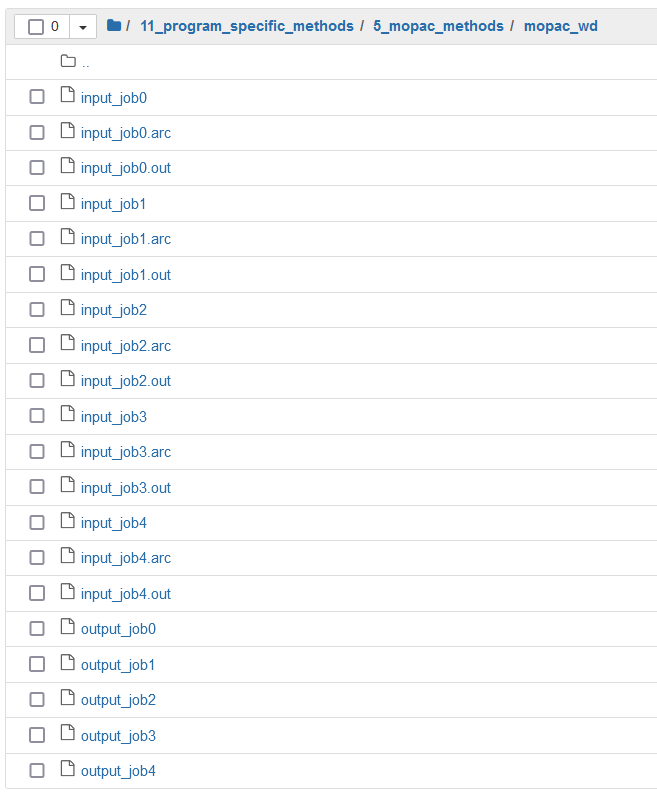

## 4. Reading molecular orbitals, CI energies, CI vectors, and basis SD configurations
<a name="4"></a>
[Back to TOC](#toc)

Now we are ready to parse the output files generated. This is done using `read_mopac_orbital_info` function:
<a name="read_mopac_orbital_info-1"></a>

In [19]:
help(mopac.read_mopac_orbital_info)

Help on function read_mopac_orbital_info in module libra_py.packages.mopac.methods:

read_mopac_orbital_info(params_)
    This function reads the MOs, configurations, and CI from the output files
    
    Args:
    
        params_ ( dict ): the dictionary containing key parameters
    
            * **params_["filename"]** ( string ) : the name of the file to read
            * **params_["orbital_space"]** (list of ints): the orbital numbers to be included, the indexing starts with 1, not 0 [default: None]
            * **params_["nstates"]** ( int ): the number of CI states + ground state to use, `nstates = 2` means 1 ground and 1 excited states
    
    Returns:
        (info, MOs, data):
    
            * info (dict): the key numbers (see the notes below)
            * MOs - (np.ndarray; shape = [nao, nact]): the matrix of MO-LCAO coefficients for active MOs
            * data ( list of 3 elements):
              - data[0] - list of `nstates-1` excited (not including the ground st

In this example code, we read the MOs, CI coeffs and configurations from the two consecutive steps since this is what we'll need for next step - calculation of time-overlaps

In [20]:
params = {"nstates":5, "filename":"mopac_wd/input_job0.out"}
info0, MO0, data0 = mopac.read_mopac_orbital_info(params)

params = {"nstates":5, "filename":"mopac_wd/input_job1.out"}
info1, MO1, data1 = mopac.read_mopac_orbital_info(params)

In [21]:
data0

[[0.17352173753261552,
  0.22356399985300066,
  0.2538862959832421,
  0.2538899709676234],
 [[[15, 17], [14, 16], [15, 16], [14, 17]],
  [[15, 17], [14, 16], [15, 16], [14, 17]],
  [[15, 17], [14, 16], [15, 16], [14, 17]],
  [[15, 17], [14, 16], [15, 16], [14, 17]]],
 [[-0.70444631, -0.70440802, -0.06151895, 0.06148299],
  [-0.06152609, -0.06147585, 0.70479529, -0.70405885],
  [-0.56905792, 0.56907537, -0.41951803, -0.41991776],
  [-0.41969396, 0.41974192, 0.56875623, 0.5693769]]]

In [22]:
data0[0]

[0.17352173753261552,
 0.22356399985300066,
 0.2538862959832421,
 0.2538899709676234]

In [23]:
data0[1]

[[[15, 17], [14, 16], [15, 16], [14, 17]],
 [[15, 17], [14, 16], [15, 16], [14, 17]],
 [[15, 17], [14, 16], [15, 16], [14, 17]],
 [[15, 17], [14, 16], [15, 16], [14, 17]]]

In [24]:
data0[2]

[[-0.70444631, -0.70440802, -0.06151895, 0.06148299],
 [-0.06152609, -0.06147585, 0.70479529, -0.70405885],
 [-0.56905792, 0.56907537, -0.41951803, -0.41991776],
 [-0.41969396, 0.41974192, 0.56875623, 0.5693769]]

In [25]:
info0

{'nocc': 15,
 'nelec': 30,
 'nao': 30,
 'nmo': 30,
 'nci': 5,
 'min_occ': 13,
 'max_occ': 15,
 'min_vir': 16,
 'max_vir': 18,
 'nact': 30,
 'actual_orbital_space': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30]}

## 5. Computing MO time-overlaps and CI time-overlaps
<a name="5"></a>
[Back to TOC](#toc)

In [26]:
st_mo_orb = MO0.T @ MO1
print(st_mo_orb.shape)
print(st_mo_orb)

# Make it doubled - block-matrix
st_mo = np.kron(np.eye(2), st_mo_orb)
print(st_mo.shape)
print(st_mo)

(30, 30)
[[ 9.99970081e-01  8.73454500e-04  6.35046030e-03 -2.22720900e-04
  -1.37977480e-03 -9.33334900e-04  8.76229000e-05 -5.76285100e-04
   1.46886690e-03  2.31090080e-03  1.07740700e-04  8.33117400e-04
  -2.08523000e-05 -5.49552800e-04  3.88603000e-05 -3.41727000e-05
   1.57339600e-04 -2.42967600e-04  2.50649400e-04 -6.12004000e-04
  -6.40220300e-04  5.69790800e-04 -5.49985100e-04 -1.46136040e-03
  -1.22731600e-04  9.07580000e-05  1.75740200e-04 -1.82354300e-04
   4.33862500e-04  2.13389000e-04]
 [-2.78917570e-03  9.51503222e-01  3.07492078e-01  7.69887550e-03
  -3.60828100e-04 -3.38172900e-03 -1.97520890e-03 -7.46498700e-04
  -1.37480900e-04 -1.11983890e-03  5.51924000e-05 -1.90984780e-03
   9.10960000e-04 -3.05964600e-04 -1.88347400e-04 -1.48932200e-04
  -2.68577900e-04  1.70914400e-04 -7.31441000e-05  6.56238300e-04
   4.66293900e-04  3.72716300e-04  9.10098000e-05  7.17197200e-04
  -1.49315700e-03  2.96218100e-04 -9.91535000e-04 -6.19890000e-05
   5.72708000e-05  1.72788600e-0

<a name="overlap-1"></a>

In [27]:
params = {"homo_indx":info0["nocc"], 
          "nocc":info0["nocc"] - 1, 
          "nvirt":info0["nmo"] - info0["nocc"], 
          "nelec":info0["nelec"], "nstates":info0["nci"],
          "active_space":None
         }

s = ci.overlap(st_mo, data0, data1, params)
print(s.shape)

(5, 5)


In [28]:
print(s)

[[ 9.99879969e-01+0.j  3.13843700e-03+0.j -8.29594577e-05+0.j
   3.90910848e-04+0.j  3.35107676e-04+0.j]
 [ 3.13703307e-03+0.j -9.99848517e-01+0.j  3.39816755e-06+0.j
   9.67216531e-04+0.j -5.90305407e-04+0.j]
 [-1.20363634e-04+0.j -6.39361679e-06+0.j -9.99155571e-01+0.j
   1.77091200e-02+0.j  3.30224107e-02+0.j]
 [-5.20032226e-04+0.j  4.45369940e-04+0.j  3.36756307e-02+0.j
   8.11922846e-01+0.j  5.82540801e-01+0.j]
 [-4.03583887e-05+0.j -1.03701561e-03+0.j  1.64896089e-02+0.j
  -5.83239045e-01+0.j  8.11949744e-01+0.j]]


## 6. The workflow
<a name="6"></a>
[Back to TOC](#toc)


Now, to automate the calculation of time-overlaps, vibronic and electronic Hamiltonians in the CI basis, we use the `mopac_compute_adi` function.
<a name="mopac_compute_adi-1"></a>

In [30]:
class tmp:
    pass

def mopac_compute_adi(q, params, full_id):

    # ================= Decode trajectory index =================
    Id = Cpp2Py(full_id)
    itraj = Id[-1]
    
    # ================= Extract coordinates =================
    coords = q.col(itraj)

    ndof = coords.num_of_rows
    nat = ndof // 3
    
    # ================= Safe param access =================
    params.setdefault("MO_prev", {})
    params.setdefault("data_prev", {})
    params.setdefault("s_ci_inv_prev", {})
    params.setdefault("is_first_time", {})
    params.setdefault("act_state", {})

    # ================= Read parameters =================
    # General: trajectory-agnostic
    atom_labels = params["atom_labels"]
    timestep = params.get("timestep", 0)
    energy_zero = params.get("energy_zero", 0.0 )
    orbital_space = params.get("orbital_space", None)
    nstates = params.get("nstates", 2)
    dt = params.get("dt", 1.0 * units.fs2au)
    wd_prefix = params.get("working_directory_prefix", "wd")
    mopac_input_prefix = params.get("mopac_input_prefix", "input_")
    mopac_output_prefix = params.get("mopac_output_prefix", "output_")
    mopac_run_params = params.get("mopac_run_params",
                                  "INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=2")
    do_Lowdin = params.get("do_Lowdin", True)
    nelec_act_space = params.get("nelec_act_space", None)
    

    # Trajectory-specific
    is_first_time = params["is_first_time"].get(itraj, True)
    act_state = params["act_state"].get(itraj, 0)
    
    wd = f"{wd_prefix}_itraj{itraj}"
    
    # ================= Run MOPAC =================
    mopac_params = copy.deepcopy(mopac_run_params)
    #mopac_params["StateOfInterest"] = act_state

    mopac_jobid = F"_timestep_{timestep}_traj_{itraj}"
    prms1 = {
        "atom_labels": atom_labels,
        "exe": params.get("exe", "mopac"),
        "mopac_run_params": mopac_params,
        "working_directory": wd,
        "mopac_jobid" : mopac_jobid,
        "mopac_input_prefix" : mopac_input_prefix,
        "mopac_output_prefix" : mopac_output_prefix
    }
    
    mopac.run_mopac(coords, prms1)
        
    # Read the MOPAC output
    # This is counterintuitive, but the actual output file name is derived from
    # that of the input
    read_params = {"nstates":nstates, 
                   "filename":F"{wd}/{mopac_input_prefix}{mopac_jobid}.out", 
                   "orbital_space":None}
    info, MO_curr, data_curr = mopac.read_mopac_orbital_info(read_params)

    #================= Construct active space ==================
    active_space = None
    if nelec_act_space is None:
        active_space = info["actual_orbital_space"]
    else: 
        min_indx = info["nocc"] - nelec_act_space//2 + 1
        if min_indx > info["min_occ"]:
            min_elec = ((info["nocc"] - info["min_occ"]) + 1 )*2
            raise ValueError(f"The `nelec_act_space` should be at least { min_elec }")
        active_space = list(range(min_indx, info["nmo"]+1))

    # Get the properties at the previous time-steps
    MO_prev, data_prev = None, None
    if is_first_time:
        # On the first step, assume the current properties are as the previous
        MO_prev = copy.deepcopy(MO_curr)
        data_prev = copy.deepcopy(data_curr)
        coordinates_prev = copy.deepcopy(coords)
    else:
        # Otherwise, retrieve the previously-stored data
        MO_prev = params["MO_prev"].get(itraj, MO_curr).copy()
        data_prev = params["data_prev"].get(itraj, data_curr)
        
    # Do the calculations - time-overlaps, energies, and Hvib
    obj = tmp()
    obj.ham_adi = CMATRIX(nstates, nstates)
    obj.nac_adi = CMATRIX(nstates, nstates)
    obj.hvib_adi = CMATRIX(nstates, nstates)
    obj.basis_transform = CMATRIX(nstates, nstates)
    obj.time_overlap_adi = CMATRIX(nstates, nstates)
    obj.overlap_adi = CMATRIX(nstates, nstates)

    #======================= MO ===============================
    s_mo_orb = MO_curr.T @ MO_curr
    s_mo = np.kron(np.eye(2), s_mo_orb) # Make it doubled - block-matrix

    st_mo_orb = MO_prev.T @ MO_curr
    st_mo = np.kron(np.eye(2), st_mo_orb) # Make it doubled - block-matrix


    #================= Compute CI time-overlaps ============= 
    ovlp_params = {"homo_indx":info["nocc"], 
                   "nocc":info["nocc"] - 1, 
                   "nvirt":info["nmo"] - info["nocc"], 
                   "nelec":info["nelec"], "nstates":nstates,
                   "active_space":active_space
                   }
    st_ci = ci.overlap(st_mo, data_prev, data_curr, ovlp_params)
    s_ci = ci.overlap(s_mo, data_curr, data_curr, ovlp_params)

    s_ci_inv_curr, s_ci_inv_prev = None, None
    if do_Lowdin==True:
        # Lowding orthogonalization to fight the rounding errors
        s_ci_inv_curr = ortho.lowdin_inverse_sqrt(s_ci)
        
        if is_first_time:
            s_ci_inv_prev = copy.deepcopy(s_ci_inv_curr)
        else:
            s_ci_inv_prev = params["s_ci_inv_prev"].get(itraj, s_ci_inv_curr)

        s_ci = s_ci_inv_curr @ s_ci @ s_ci_inv_curr
        st_ci = s_ci_inv_prev @ st_ci @ s_ci_inv_curr


    #=============== Now, populate the allocated matrices ======================
    for istate in range(nstates):
        energ = 0.0
        if istate > 0:
            #energ = float(0.5 * (data_prev[0][istate-1] + data_curr[0][istate-1]))
            energ = float(data_curr[0][istate-1])

        obj.ham_adi.set(istate, istate, energ * (1.0 + 0.0j))
        obj.hvib_adi.set(istate, istate, energ * (1.0 + 0.0j))
        obj.basis_transform.set(istate, istate, 1.0 + 0.0j)  # assume identity

        for jstate in range(nstates):
            obj.time_overlap_adi.set(istate, jstate, float(st_ci[istate, jstate]) * (1.0 + 0.0j))
            obj.overlap_adi.set(istate,  jstate, float(s_ci[istate, jstate]) * (1.0 + 0.0j) )

    # Update the Hvib:
    for istate in range(nstates):
        for jstate in range(istate + 1, nstates):
            dij = (obj.time_overlap_adi.get(istate, jstate) - obj.time_overlap_adi.get(jstate, istate)) / (2.0 * dt)
            obj.hvib_adi.set(istate, jstate, dij * (0.0 - 1.0j))
            obj.hvib_adi.set(jstate, istate, dij * (0.0 + 1.0j))

    # Now, make the current the previous and reset the flag `is_first_time` to False
    # Note - we directly modify the input parameters
    
    # ================= Store state =================
    params["MO_prev"][itraj] = MO_curr.copy()
    params["data_prev"][itraj] = copy.deepcopy(data_curr)
    params["s_ci_inv_prev"][itraj] = copy.deepcopy(s_ci_inv_curr)
    params["is_first_time"][itraj] = False

    return obj

And its libra implementation:

In [31]:
help(mopac.mopac_compute_adi)

Help on function mopac_compute_adi in module libra_py.packages.mopac.methods:

mopac_compute_adi(q, params, full_id)
    Compute adiabatic-state energies, overlaps, time-overlaps, and vibronic
    Hamiltonian matrix elements using MOPAC electronic structure calculations.
    
    This function serves as a Libra-compatible electronic structure interface
    for nonadiabatic molecular dynamics simulations. For a given trajectory,
    it executes a MOPAC calculation, reads molecular orbital and configuration
    interaction (CI) information, computes adiabatic-state energies and
    time-overlaps between consecutive time steps, and constructs the vibronic
    Hamiltonian in the adiabatic representation.
    
    The function maintains trajectory-specific electronic structure data
    (molecular orbitals, CI vectors, and overlap matrices) between successive
    calls through the ``params`` dictionary, enabling the evaluation of
    nonadiabatic couplings via finite differences of wavefunct

This function is set up in the same way as model Hamiltonians or the file-based Hamiltonians used in the atomistic workflows. This way, it could be extended to the non-NBRA calculations and passed to the dynamics functions. 

Unlike many other caases, the parameters are passed not as a dictionary, but as a list of dictionaries. The number of dictionaries is the same as the number of trajectories to be computed. This is done so that the dictionary for each trajectory could keep the prior values of some properties such as CI vectors, in order to compute the time-overlaps. In the situation when the function would be called for several trajectories, using only one parameters dictionary could lead to unwanted data sharing and corruption whcih could lead to incorrect results. 

In addition to all other parameters, the dictionaries contain the `timestep` keyword, which is progressed along the way and is used to access a particular snapshot in the pre-computed trajectory. 

Another variable stored in the parameters dictionaries is `is_first_time`. It is used to check if the current calculation is the first one for the given trajectory. In this case, the current and previous values would be the same (in which case the time-overlap should be an identity matrix). After the first call of the function, this flag is set to False, to tell the future calculations that one can use previously-stored variables. 

In the `mopac_run_params` it is useful to choose the following parameter: `WRTCI=n`, where n is the number of states (first state is the ground-state) to print-out. If not set, the number of the CI states printed at different geometries may vary, which would lead to the incorrect structure of the computed matrices (may be non-square matrices). 

In this example, the `full_id` is set up to mimic a ssingle trajectory. If called by the main dynamical function, this variable would have been setup automatically for each trajectory.

For simplicity, in the present example, the working directory is set up differently from the directory used in the above examples. This would be the directory for both the MOPAC input and output files, but also this is where the computed properties will be saved as text files. These properties are contained in the object `obj` returned by the `mopac_compute_adi` function.

In [34]:
%%time 

labels, q = cp2k.read_trajectory_xyz_file("1_ring-pos-1.xyz", 0)
params_elem = {"atom_labels":labels, 
               "timestep": 0,
               "exe":"/projects/academic/cyberwksp21/SOFTWARE/mopac/build/mopac", 
               "mopac_run_params":"INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5",
               "working_directory_prefix":"workflow_wd",
               "mopac_input_prefix":"benzene_", 
               "mopac_output_prefix":"output_", 
               "nstates":5,
               "dt":1.0*units.fs2au,
               "do_Lowdin":False,
               
               "is_first_time":{0:True},
               "act_state":{0:1},
              }

# For 1 trajectory
print(params_elem)

{'atom_labels': ['C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H'], 'timestep': 0, 'exe': '/projects/academic/cyberwksp21/SOFTWARE/mopac/build/mopac', 'mopac_run_params': 'INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5', 'working_directory_prefix': 'workflow_wd', 'mopac_input_prefix': 'benzene_', 'mopac_output_prefix': 'output_', 'nstates': 5, 'dt': 41.339396444811904, 'do_Lowdin': False, 'is_first_time': {0: True}, 'act_state': {0: 1}}
CPU times: user 12.2 ms, sys: 5.85 ms, total: 18.1 ms
Wall time: 25.6 ms


In [36]:
# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

res = "results"
# Create working directory, if doesn't exist
if not os.path.exists(res):
    os.mkdir(res)

# Do the first 5 steps 
for i in range(5):
    print(F"======== Iteration {i} ==============")
    labels, q = cp2k.read_trajectory_xyz_file("1_ring-pos-1.xyz", i)
    params_elem["timestep"] = i
    
    #Try one version or the other
    #obj = mopac_compute_adi(q, params_elem, full_id)        
    obj = mopac.mopac_compute_adi(q, params_elem, full_id)        
    obj.ham_adi.show_matrix(F"{res}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{res}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{res}/st_adi_{i}.txt")
    obj.overlap_adi.real().show_matrix(F"{res}/s_adi_{i}.txt")
    

======== Iteration 0 ==============
======== Iteration 1 ==============
======== Iteration 2 ==============
======== Iteration 3 ==============
======== Iteration 4 ==============
